In [16]:
import torch
import os
import numpy as np
import torch
import random
import pickle
import datetime
import argparse
import pandas as pd

from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from models.DeepSleepSota2D import DeepSleepSota2D
from models.DeepSleepAttn2D import *
from utils.eval_helper import event_level_analysis
from utils.tools import load_edf_file, save_arousal_xml, load_edf_only
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

def str2bool(v):
    if isinstance(v, bool):
       return v
    if v.lower() in ('yes','true','t','y','1'):
        return True
    elif v.lower() in ('no','false','f','n','0'):
        return False
    else:
        raise argparse.ArgumentTypeError('Boolean value expected.')


def save_to_xml(edf_path, y, save_path, sfreq=50, base_time=None):
    if base_time is None:
        raw = load_edf_file(
            edf_path, 
            preload=True, 
            resample=100, 
            preset="STAGENET", 
            exclude=True, 
            missing_ch='raise'
        )
        base_time = raw.info['meas_date']
    else:
        base_time = datetime.strptime(base_time, "%Y-%m-%d %H:%M:%S")
    save_arousal_xml(base_time, y, sfreq, save_path, min_duration=3)


def postprocess_arousal_preds(preds, min_len=5, fs=50):
    min_event_samples = int(min_len * fs)
    
    # 결과를 저장할 새로운 preds (모두 0으로 초기화)
    new_preds = np.zeros_like(preds, dtype=int)
    
    in_event = False
    start_idx = 0
    length = len(preds)

    for i in range(length):
        if not in_event:
            # 이벤트가 시작되지 않은 상태에서 1을 만나면 이벤트 시작
            if preds[i] == 1:
                in_event = True
                start_idx = i
        else:
            # 이미 이벤트 중이었고, 현재 0이거나 마지막 인덱스면 이벤트가 끝났다고 판단
            if preds[i] == 0 or i == length - 1:
                # 종료 지점 계산
                if preds[i] == 0:
                    end_idx = i - 1
                else:
                    end_idx = i  # 마지막 인덱스까지 1이었다면 i가 이벤트 끝
                
                # 이벤트 길이
                event_len = end_idx - start_idx + 1
                
                if event_len >= min_event_samples:
                    if end_idx >= start_idx:
                        new_preds[start_idx: end_idx + 1] = 1
                
                in_event = False

    return new_preds


class ChunkedSpecArousalDataset(Dataset):
    def add_chunk(self, file_idx, start_idx, end_idx, y):
        chunk = (file_idx, start_idx, end_idx)
        self.chunks.append(chunk)
        self.idx_to_chunk[len(self.chunks) - 1] = chunk

    def remove_corrupted_chunks(self, corrupted_chunk_idxs):
        for corrupted_chunk_idx in corrupted_chunk_idxs:
            self.chunks.remove(self.idx_to_chunk[corrupted_chunk_idx])
        
        for idx in range(len(self.chunks)):
            self.idx_to_chunk[idx] = self.chunks[idx]

    def __init__(self, file_paths, n_window=4, normalize=False, test=False):
        super().__init__()
        self.file_paths = file_paths
        self.n_window = n_window
        self.normalize = normalize
        self.test = test

        self.chunks_for_file = {}
        self.chunks = []
        self.corrupted_chunks = []
        self.idx_to_chunk = {}
        
        for file_idx, path in enumerate(self.file_paths):
            with open(path, 'rb') as f:
                data_dict = pickle.load(f)
            x = data_dict['x']  # shape: (C, F, T)
            y = data_dict['y']  # shape: (T,)
            
            total_len = x.shape[-1]  # T (time dimension)
            if total_len < self.n_window:
                self.add_chunk(file_idx, 0, total_len, y[0:total_len])
                continue

            chunk_size = total_len // self.n_window  # 몫
            remainder  = total_len %  self.n_window
            
            start_idx = 0
            for w_idx in range(self.n_window):
                # 남은 remainder를 고려해서 분배 가능(여기서는 마지막 chunk에 몰아주기 예시)
                if w_idx < self.n_window - 1:
                    end_idx = start_idx + chunk_size
                else:
                    end_idx = total_len
                
                if end_idx - start_idx < chunk_size:
                    raise ValueError(f"Invalid chunk size: {start_idx} ~ {end_idx}")

                self.add_chunk(file_idx, start_idx, end_idx, y[start_idx:end_idx])

                start_idx = end_idx  # 다음 chunk 시작

            if not test:
                self.add_chunk(file_idx, chunk_size//2, chunk_size//2 + chunk_size, y[chunk_size//2:chunk_size//2 + chunk_size])

            self.chunks_for_file[file_idx] = self.chunks
            self.chunks = []


    def __len__(self):
        return len(self.chunks_for_file)

    def __getitem__(self, idx):
        chunks = []

        # file_idx, st, en = self.chunks[idx]
        path = self.file_paths[idx]
        with open(path, 'rb') as f:
            data_dict = pickle.load(f)

        x = data_dict['x']  # (C, F, T)
        y = data_dict['y']  # (T,)
        
        for chunk in self.chunks_for_file[idx]:
            file_idx, st, en = chunk
            x_chunk = x[:, :, st:en]
            y_chunk = y[st:en]
            x_chunk = torch.from_numpy(x_chunk).float()
            y_chunk = torch.from_numpy(y_chunk).long()  # or float if BCE
            chunks.append((x_chunk, y_chunk))

        info = {
            'freqs': data_dict['freqs'],
            'times': data_dict['times'],
            'y_time': data_dict['y_time'],
            'total_samples': len(data_dict['y_time']) 
        }

        return chunks, info, idx

def map_spec_pred_to_time(
    pred_1d,        # shape: (time_bins,) => STFT each bin의 예측값 (0~1 등)
    times,          # shape: (time_bins,) => make_spectrogram의 STFT 윈도우 중심 시각(초)
    total_samples,  # 원본 시계열 전체 샘플 수
    fs=50,          # 샘플링 레이트
    nperseg=50,     # STFT 윈도우 크기(샘플)
    mode='average'
):
    # 윈도우 중심으로부터 앞뒤 절반 길이(초 단위)
    half_win_sec = nperseg / (2.0 * fs)  # 예: 2초 윈도우라면 1초
    
    y_time = np.zeros(total_samples, dtype=np.float32)
    count  = np.zeros(total_samples, dtype=np.float32)  # 몇 개 윈도우가 겹쳤는지 기록

    time_bins = len(times)

    for i in range(time_bins):
        center_sec = times[i]       # i번째 bin 중심 시각 (초)
        start_sec = center_sec - half_win_sec
        end_sec   = center_sec + half_win_sec
        
        # 원본 샘플 인덱스로 환산
        start_idx = int(np.floor(start_sec * fs))
        end_idx   = int(np.ceil(end_sec * fs))
        
        # 유효 범위로 자르기
        if start_idx < 0:
            start_idx = 0
        if end_idx > total_samples:
            end_idx = total_samples

        if start_idx >= end_idx:
            continue
        
        if mode == 'average':
            # 해당 구간에 pred_1d[i]를 누적
            y_time[start_idx:end_idx] += pred_1d[i]
            count[start_idx:end_idx]  += 1.0
        
        elif mode == 'max':
            # 기존 값과 비교해 최댓값
            y_time[start_idx:end_idx] = np.maximum(
                y_time[start_idx:end_idx],
                pred_1d[i]
            )
        # 필요하다면 다른 방식(가중 합 등)도 가능

    if mode == 'average':
        # 겹친 구간 개수로 나눠 평균
        nonzero_mask = (count > 0)
        y_time[nonzero_mask] /= count[nonzero_mask]

    return y_time


def spec_collate_fn(batch_list):
    # 1) freq는 동일하다고 보고, time 크기만 확인
    max_time = 0
    freq_dim = 0
    for (x, y, info, idx) in batch_list:
        _, f, t = x.shape
        freq_dim = f
        if t > max_time:
            max_time = t
   
    batch_size = len(batch_list)
    
    x_batch = torch.zeros(batch_size, 9, freq_dim, max_time, dtype=torch.float)
    y_batch = torch.zeros(batch_size, max_time, dtype=torch.float) + -1  # -1로 padding
    
    idx_list = []
    info_list = []
    
    for i, (x, y, info, idx) in enumerate(batch_list):
        c, f, t = x.shape
        x_batch[i, :, :, :t] = x
        y_batch[i, :t] = y
        idx_list.append(idx)
        info_list.append(info)
    
    idx_tensor = torch.LongTensor(idx_list)
    
    return x_batch, y_batch, info_list, idx_tensor
 

def eval_fn2(model, loader, device):
    model.eval()

    all_probs   = []   # 예측 확률 (길이 = 전체 샘플 수)
    all_targets = []   # 정답 (0/1)

    with torch.no_grad():
        for chunks, info, _ in loader:
            # ───────── 여러 window(chunk) → 하나로 이어붙이기 ─────────
            y_preds = []
            pad_masks = []
            for x, y in chunks:
                x = x.to(device)
                y = y.to(device)

                y_pred_2d = model(x)          # (B,1,F,T)
                y_pred_1d = y_pred_2d.mean(2) # freq-pool → (B,1,T)
                pad_mask  = (y != -1)

                y_pred_1d = y_pred_1d.squeeze(1)
                y_pred_1d[~pad_mask] = 0.0
                y[~pad_mask]         = 0
                y_preds.append(y_pred_1d)
                pad_masks.append(pad_mask)

            # (1) 시간축 따라 concat
            y_pred_1d = torch.cat(y_preds,  dim=1)        # 확률
            pad_mask  = torch.cat(pad_masks, dim=1).squeeze()

            # (2) 시간-단위 확률을 원본 샘플 단위로 뿌리기
            times          = info['times'].squeeze()
            total_samples  = info['total_samples']
            y_prob_time = map_spec_pred_to_time(
                y_pred_1d[0][pad_mask].cpu().numpy(),
                times,
                total_samples, fs=50, nperseg=50
            )
            y_true_time = info['y_time'].reshape(-1)

            # (3) PR커브 계산용 리스트에 누적
            all_probs.append(y_prob_time)
            all_targets.append(y_true_time.cpu().numpy().astype(int))

    # ───────── 전체 파일/윈도우를 이어붙임 ─────────
    y_scores = np.concatenate(all_probs)
    y_true   = np.concatenate(all_targets)

    # Precision–Recall 곡선 및 AP
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    avg_prec = average_precision_score(y_true, y_scores)

    # F1 = 2PR / (P+R), thresholds 길이에 맞추기 위해 마지막 점 제외
    f1s = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-8)
    best_idx = np.argmax(f1s)
    best_th  = thresholds[best_idx]
    best_f1  = f1s[best_idx]

    return {
        "precision": precision,
        "recall": recall,
        "thresholds": thresholds,
        "avg_precision": avg_prec,
        "best_th": best_th,
        "best_f1": best_f1,
        "y_true": y_true,
        "y_scores": y_scores,
        "best_idx": best_idx, 
    }


def main(edf_path, save_path=None):
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    device = f'cuda:{0}' if torch.cuda.is_available() else 'cpu'

    arousal_dir = os.path.dirname(edf_path).replace("EDF", "AROUS_SPEC")
    arousal_dir = "/home/honeynaps/data/GOLDEN/AROUS_SPEC"
    test_dir = f"{arousal_dir}/AROUSAL_SPEC_50_PAD_tight"
    test_dir = f"{arousal_dir}/AROUSAL_SPEC_50_PAD_tech_robust_scale"

    edf_name = os.path.basename(edf_path)
    val_files = [os.path.join(test_dir, edf_name.replace(".edf", ".pkl"))]
    
    # model
    model = DeepSleepSota2D(in_channels=9).to(device)
    model = DeepSleepAttn2D(in_channels=9, 
                            base_ch=16, num_layers=4,
                            transformer_layers=2,
                            nhead=4, dropout=0.25).to(device)
    pretrained_path = "/home/honeynaps/data/saved_models_spec/NSSpecattn_dsW[2, 4, 6]__f1_0.8149__PAD_tech_robust_scaleno_act_lr0.0010_fs50_ep25_auprc0.8887_th0.5931.pt" # W1, 0.7995
    
    # pretrained_path = "/home/honeynaps/data/saved_models_spec/NSSpecattn_dsW[2, 4, 6]__f1_0.7888__PAD_tech_robust_scaleno_g2_yes_g1_lr0.0010_fs50_ep20_auprc0.8630_th0.5959.pt" 
    th = float(pretrained_path.split('_')[-1].replace('.pt', '').replace('th', ''))
    # n_windows = int(pretrained_path.split('ChunkSpecW')[1][0])

    val_dataset  = ChunkedSpecArousalDataset(
        file_paths=val_files,
        n_window=1,
        test=True
    )
    val_loader   = DataLoader(val_dataset,
                              batch_size=4,
                              shuffle=False,
                              num_workers=1)


    model.load_state_dict(torch.load(pretrained_path, map_location=device, weights_only=True))
      
    metrics = eval_fn2(model, val_loader, device)

    print(f"Avg-Precision (AP) : {0.8810:.4f}")
    print(f"Best  F1           : {metrics['best_f1']:.4f} @ threshold = {metrics['best_th']:.4f}")

    # ─── PR 커브 그리기 & 베스트 F1 표시 ───
    plt.figure(figsize=(6, 5))
    plt.step(metrics["recall"], metrics["precision"], where="post", label="PR curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall (AP = {0.8810:.4f})")
    plt.grid(True)

    # ▶ 베스트 F1 지점 좌표
    best_P = metrics["precision"][metrics["best_idx"]]
    best_R = metrics["recall"][metrics["best_idx"]]

    # ● 점 + 텍스트 주석
    plt.scatter(best_R, best_P, s=80, marker="o", color="red", zorder=3, label="Best F1")
    plt.annotate(
        f"F1={0.8024:.3f}\nth={metrics['best_th']:.3f}",
        xy=(best_R, best_P),
        xytext=(best_R + 0.03, best_P - 0.05),
        arrowprops=dict(arrowstyle="->", lw=1.2),
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8),
    )

    plt.legend(loc="lower left")

    pr_curve_path = "pr_curve.png"          # 원하는 경로/파일명으로 변경 가능
    plt.show()




Processing /home/honeynaps/data/GOLDEN/EDF2/SCH_M_40_NW_230126R4_MI.edf
Avg-Precision (AP) : 0.8810
Best  F1           : 0.7933 @ threshold = 0.5875


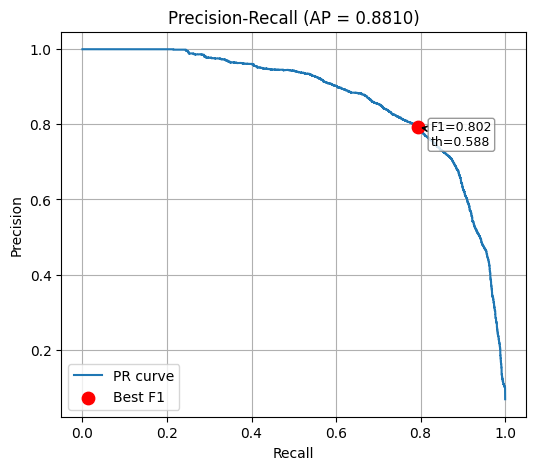


Processing /home/honeynaps/data/GOLDEN/EDF2/SCH_F_20_OV_230715R3_MO.edf
Avg-Precision (AP) : 0.8810
Best  F1           : 0.7657 @ threshold = 0.5996


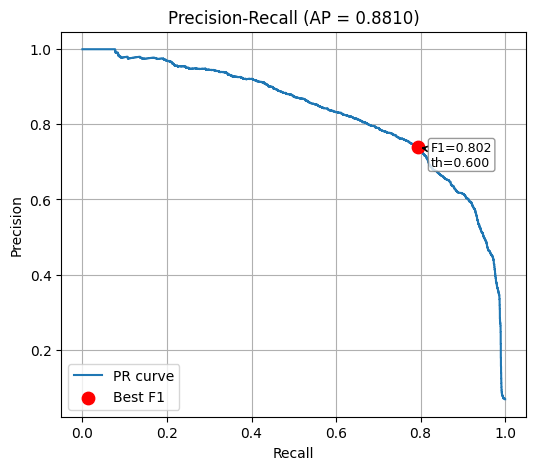


Processing /home/honeynaps/data/GOLDEN/EDF2/SCH_F_20_OB_231128R4_NO.edf
Avg-Precision (AP) : 0.8810
Best  F1           : 0.7665 @ threshold = 0.5865


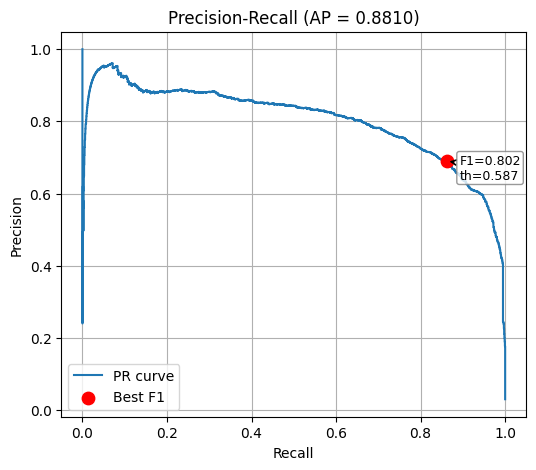


Processing /home/honeynaps/data/GOLDEN/EDF2/SCH_F_50_NW_230105R3_MO.edf
Avg-Precision (AP) : 0.8810
Best  F1           : 0.7590 @ threshold = 0.5826


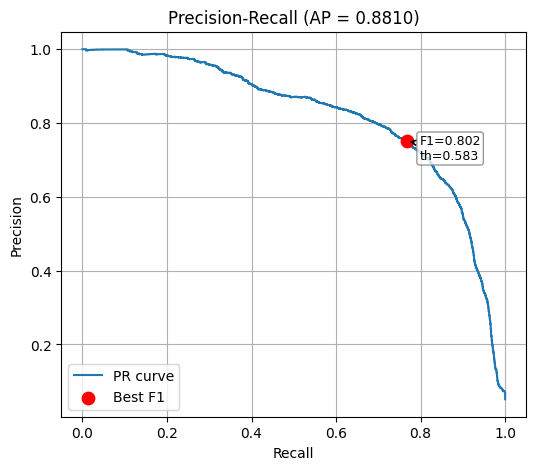


Processing /home/honeynaps/data/GOLDEN/EDF2/SCH_F_60_OV_221217R4_SE.edf
Avg-Precision (AP) : 0.8810
Best  F1           : 0.8352 @ threshold = 0.6644


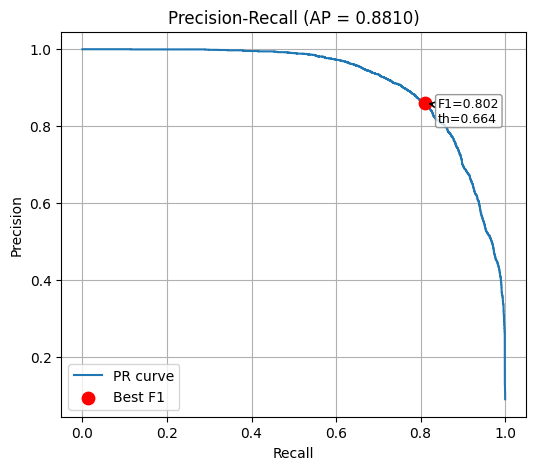


Processing /home/honeynaps/data/GOLDEN/EDF2/SCH_F_40_OB_231125R4_SE.edf
Avg-Precision (AP) : 0.8810
Best  F1           : 0.7978 @ threshold = 0.6474


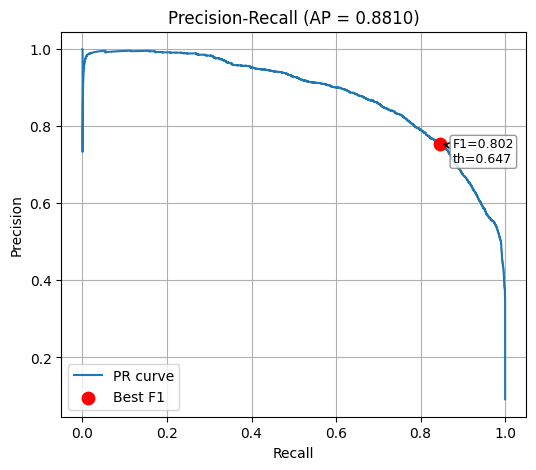


Processing /home/honeynaps/data/GOLDEN/EDF2/SCH_F_60_NW_230926R3_SE.edf
Avg-Precision (AP) : 0.8810
Best  F1           : 0.7975 @ threshold = 0.5851


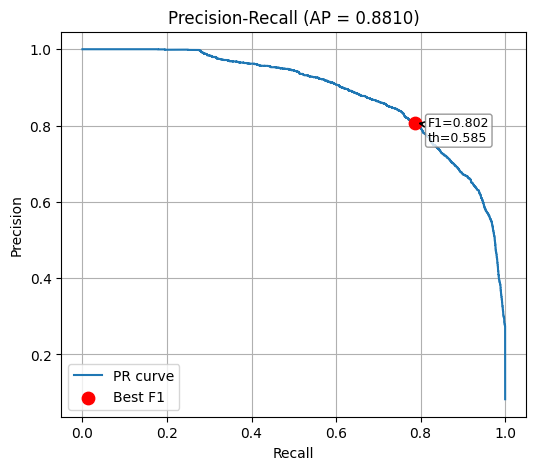


Processing /home/honeynaps/data/GOLDEN/EDF2/SCH-230114R3_M-60-OV-SE.edf
Avg-Precision (AP) : 0.8810
Best  F1           : 0.8745 @ threshold = 0.6254


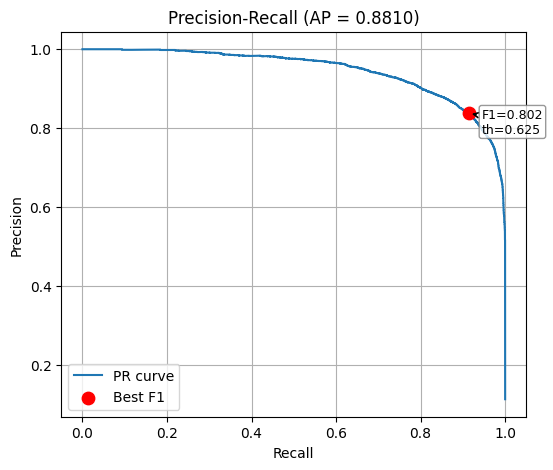


Processing /home/honeynaps/data/GOLDEN/EDF2/SCH_F_40_NW_230511R3_SE.edf
Avg-Precision (AP) : 0.8810
Best  F1           : 0.8171 @ threshold = 0.6171


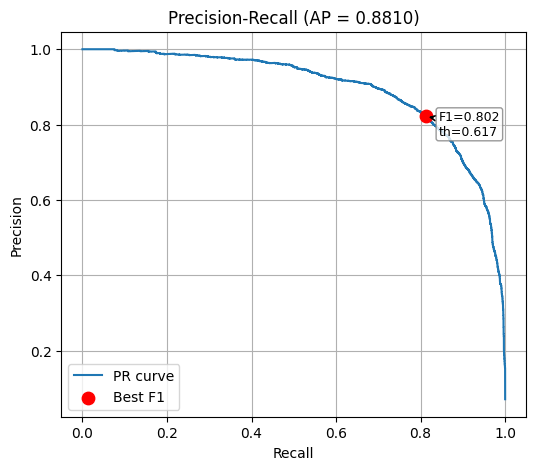


Processing /home/honeynaps/data/GOLDEN/EDF2/SCH_M_30_NW_230110R4_MI.edf
Avg-Precision (AP) : 0.8810
Best  F1           : 0.8167 @ threshold = 0.5681


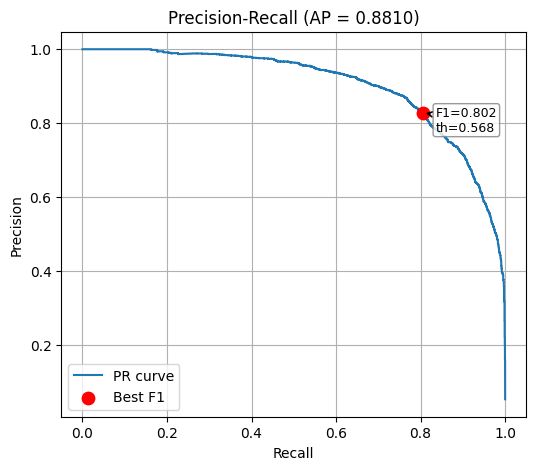


Processing /home/honeynaps/data/GOLDEN/EDF2/SCH_F_40_NW_231130R4_MO.edf
Avg-Precision (AP) : 0.8810
Best  F1           : 0.7895 @ threshold = 0.6408


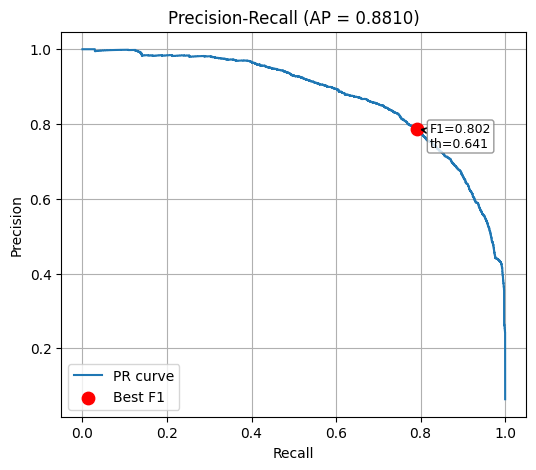


Processing /home/honeynaps/data/GOLDEN/EDF2/SCH_M_30_NW_230325R4_MO.edf
Avg-Precision (AP) : 0.8810
Best  F1           : 0.7801 @ threshold = 0.6480


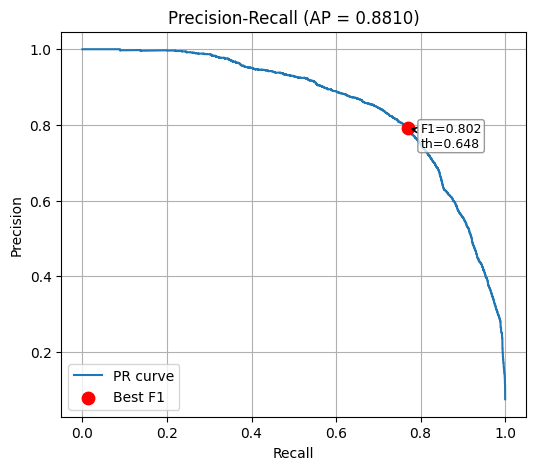


Processing /home/honeynaps/data/GOLDEN/EDF2/SCH_F_60_NW_230921R4_NO.edf
Avg-Precision (AP) : 0.8810
Best  F1           : 0.7075 @ threshold = 0.5974


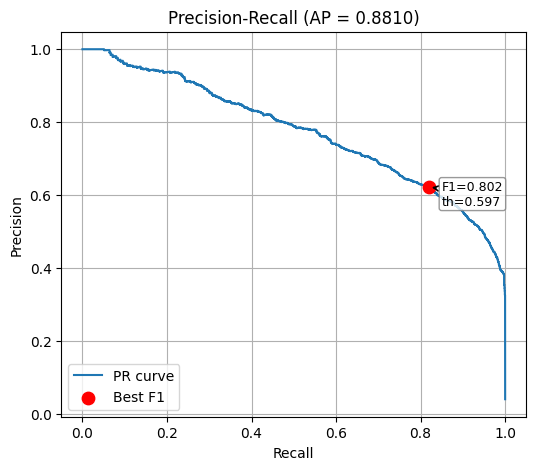


Processing /home/honeynaps/data/GOLDEN/EDF2/SCH_M_30_OB_230617R3_SE.edf
Avg-Precision (AP) : 0.8810
Best  F1           : 0.8364 @ threshold = 0.6417


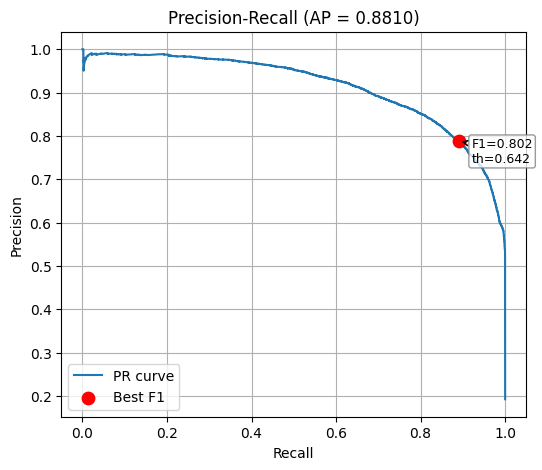


Processing /home/honeynaps/data/GOLDEN/EDF2/SCH_M_20_OV_230330R3_MI.edf
Avg-Precision (AP) : 0.8810
Best  F1           : 0.8235 @ threshold = 0.5889


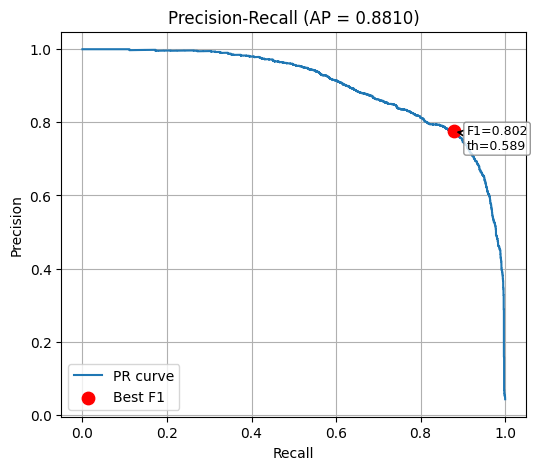

In [17]:
edf_dir = "/home/honeynaps/data/GOLDEN/EDF2"
edf_files = [f for f in os.listdir(edf_dir) if f.endswith(".edf")]
edf_files = [f for f in edf_files if "SCH_M_20_OV_230111R1_NO" not in f]

stats_header = ["edf_name",
                "n_events_found", 
                "n_events_missed",
                "n_events_unmatched",
                "detection_ratio",
                "mean_overlap_ratio",
                "avg_front_overhang",
                "avg_back_overhang",
                "avg_front_underhang",
                "avg_back_underhang",
                "matched_pred_ratio",
                "acc", "precision", "recall", "f1"]
stat_lines = [stats_header]
avg_acc, avg_precision, avg_recall, avg_f1 = 0, 0, 0, 0
for edf_file in edf_files:
    edf_path = os.path.join(edf_dir, edf_file)
    print("\nProcessing", edf_path)
    main(edf_path, None)
